OpenCV Version: 4.13.0
Pytesseract Version: 0.3.13
Pages loaded: 1


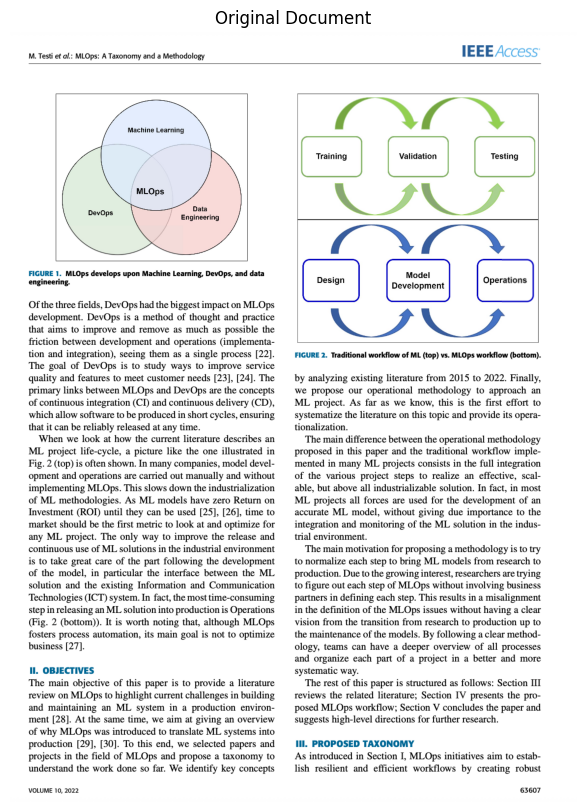

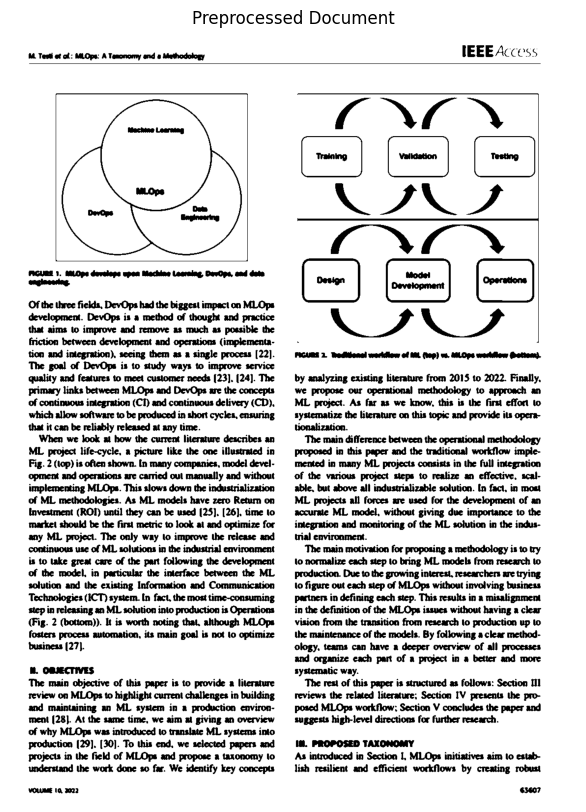

===== OCR TEXT =====
MM. Testi ot al: MLOps: A Teaonomy end » Methodology IEEE Access
ee
enginwering, Development

Of the three fields, DevOps had the biggest impact on MLOps

developmem. DevOps is a method of thought and practice

that aims to improve and remove as much as possible the

tion and integration). seeing them as a single process [22]. FIGURE 2. Weditdonel werkdlow of IML (top) ve, MLOps werlllow bottom).
The goal of DevOps is to study ways to improve service

quality and features to meet customer needs [23]. [24]. The by analyzing existing literature from 2015 to 2022. Finally.
primary links between MLOps and DevOps are the concepts we propose our operational methodology to approach an
of continuous integration (CI) and continuous delivery (CD), ML project. As far as we know, this is the first effort to
which allow software to be produced in short cycles, ensuring systematize the literature on this topic and provide its opera-
that it can be reliably released at any time. 

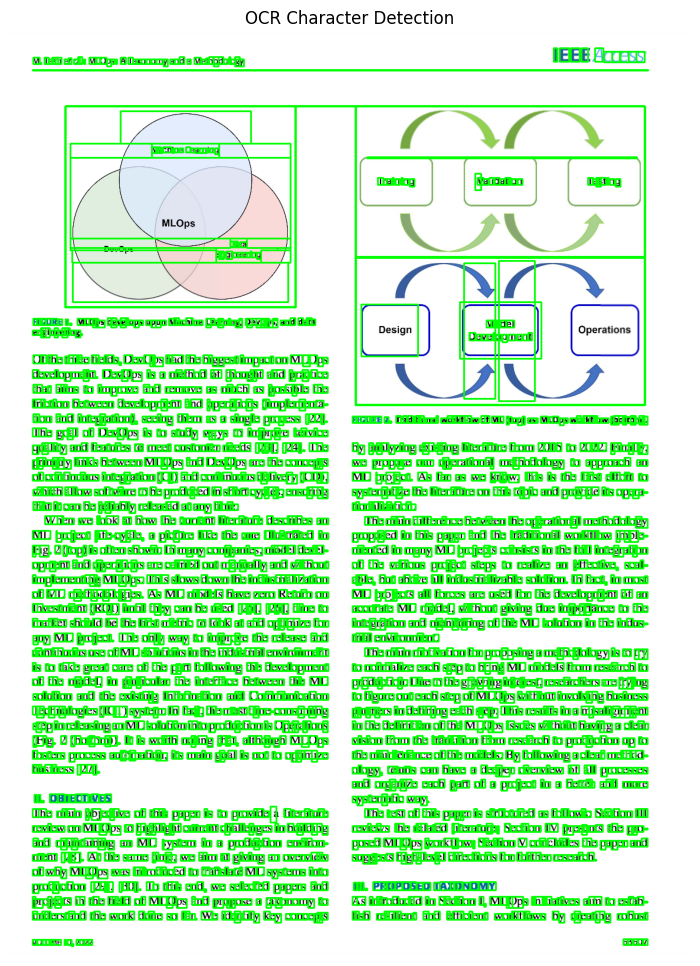

===== OCR DATAFRAME =====


,level,page_num,block_num,par_num,line_num,word_num,left,top,width,height,conf,text
4,5,1,1,1,1,1,38,31,16,34,69,M.
5,5,1,1,1,1,2,59,31,29,34,84,Testi
6,5,1,1,1,1,3,93,31,9,34,67,ot
7,5,1,1,1,1,4,110,31,17,34,89,al:
8,5,1,1,1,1,5,136,31,46,34,59,MLOps:
9,5,1,1,1,1,6,189,43,7,11,93,A
11,5,1,1,1,1,8,272,31,23,34,80,end
13,5,1,1,1,1,10,314,31,86,34,77,Methodology
22,5,1,3,1,1,1,39,63,1041,3,95,
26,5,1,4,1,1,1,93,124,983,4,95,


Total OCR Words: 654
===== TOKENS =====
['MM', '.', 'Testi', 'ot', 'al', ':', 'MLOps', ':', 'A', 'Teaonomy', 'end', '»', 'Methodology', 'IEEE', 'Access', '\n', 'ee', '\n', 'enginwering', ',', 'Development', '\n\n', 'Of', 'the', 'three', 'fields', ',', 'DevOps', 'had', 'the']

===== CLEAN TOKENS =====
['mm', 'testi', 'ot', 'al', 'mlops', 'teaonomy', 'end', 'methodology', 'ieee', 'access', 'ee', 'enginwere', 'development', 'field', 'devops', 'big', 'impact', 'mlops', 'developmem', 'devops', 'method', 'thought', 'practice', 'aim', 'improve', 'remove', 'possible', 'tion', 'integration', 'see']

Total Clean Tokens: 335
===== TOP TF-IDF WORDS =====


,word,score
112,ml,0.455173
113,mlops,0.394483
144,project,0.242759
115,model,0.182069
109,methodology,0.151724
143,production,0.151724
98,literature,0.151724
132,paper,0.151724
174,step,0.151724
37,devops,0.121379


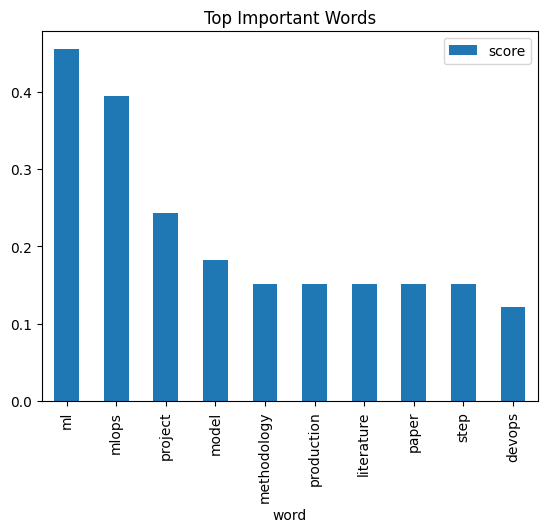

===== NAMED ENTITIES =====
('MM', 'GPE')
('Teaonomy', 'GPE')
('three', 'CARDINAL')
('DevOps', 'ORG')
('MLOps', 'ORG')
('DevOps', 'ORG')
('22', 'CARDINAL')
('2', 'CARDINAL')
('IML', 'ORG')
('MLOps', 'ORG')
('DevOps', 'ORG')
('23', 'CARDINAL')
('24', 'CARDINAL')
('2015', 'DATE')
('MLOps', 'ORG')
('DevOps', 'ORG')
('CI', 'ORG')
('ML', 'ORG')
('first', 'ORDINAL')
('ML', 'ORG')
Number of contours found: 3


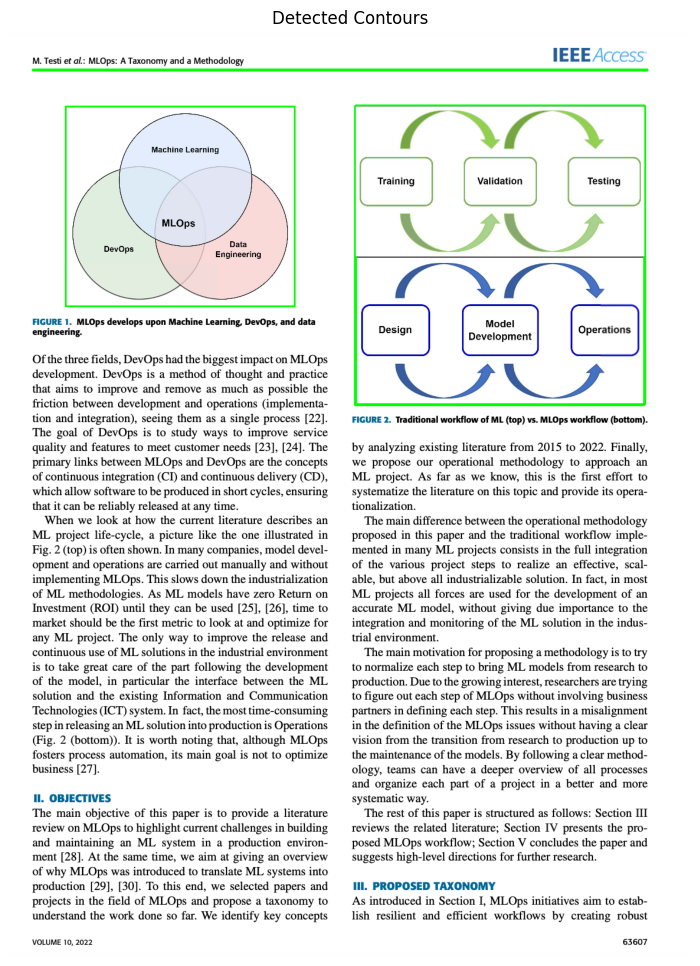

===== CAPTIONS =====
['FIGURE 2. Weditdonel werkdlow of IML (top) ve, MLOps werlllow bottom).']
===== REFERENCES =====
{'figures': ['FIGURE 2'], 'tables': []}
===== REGIONS DETECTED =====
{'x': 585, 'y': 125, 'w': 491, 'h': 508, 'label': 'diagram_or_table'}
{'x': 93, 'y': 125, 'w': 391, 'h': 342, 'label': 'diagram_or_table'}


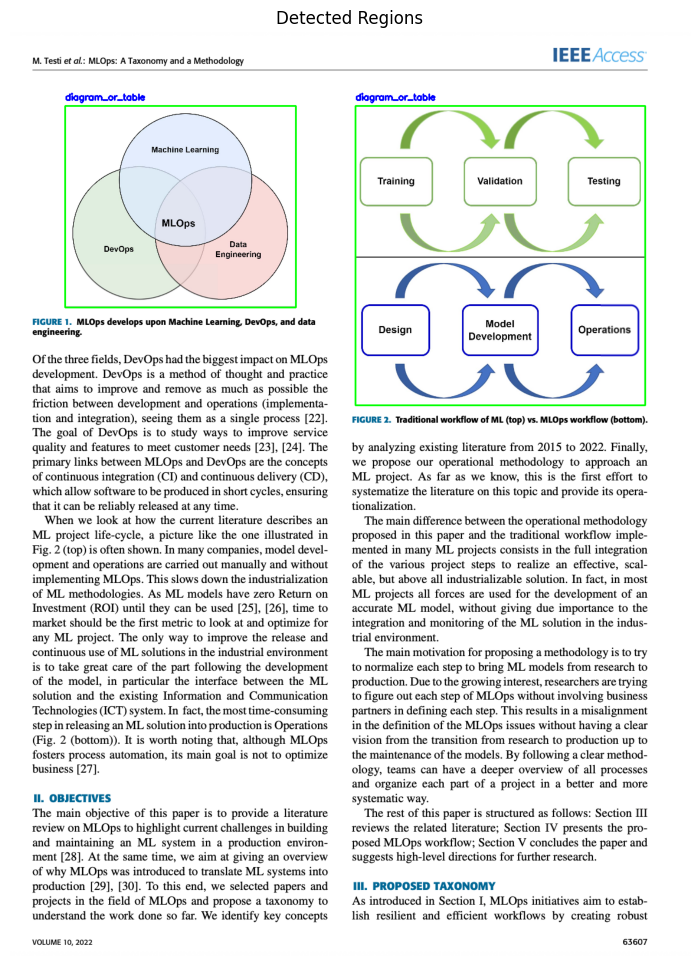

===== DOCUMENT TYPE =====
Invoice
===== FINAL REPORT =====

Document Type:
Invoice

Word Count:
335

Top Keywords:


,word,score
112,ml,0.455173
113,mlops,0.394483
144,project,0.242759
115,model,0.182069
109,methodology,0.151724
143,production,0.151724
98,literature,0.151724
132,paper,0.151724
174,step,0.151724
37,devops,0.121379



Named Entities:
[('MM', 'GPE'), ('Teaonomy', 'GPE'), ('three', 'CARDINAL'), ('DevOps', 'ORG'), ('MLOps', 'ORG'), ('DevOps', 'ORG'), ('22', 'CARDINAL'), ('2', 'CARDINAL'), ('IML', 'ORG'), ('MLOps', 'ORG')]

Captions:
['FIGURE 2. Weditdonel werkdlow of IML (top) ve, MLOps werlllow bottom).']

References:
{'figures': ['FIGURE 2'], 'tables': []}

Regions Found:
2


In [1]:
# ==========================================================
# CA2 - MULTI-MODAL DOCUMENT UNDERSTANDING SYSTEM
# AI for Vision and NLP
# ==========================================================

# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================

import os
import re
import cv2
import fitz
import pytesseract
import spacy
import pandas as pd
import matplotlib.pyplot as plt

from pytesseract import Output
from sklearn.feature_extraction.text import TfidfVectorizer

%matplotlib inline


# ==========================================================
# 2. LOAD NLP MODEL + TESSERACT
# ==========================================================

pytesseract.pytesseract.tesseract_cmd = r"C:\Tesseract\tesseract.exe"

nlp = spacy.load("en_core_web_sm")

print("OpenCV Version:", cv2.__version__)
print("Pytesseract Version:", pytesseract.__version__)


# ==========================================================
# 3. SELECT DOCUMENT
# ==========================================================

# Add your file path here
file_path = "sample_document.png"


# ==========================================================
# 4. LOAD PDF OR IMAGE
# ==========================================================

def convert_pdf_to_images(file_path):

    images = []

    doc = fitz.open(file_path)

    for page in doc:

        pix = page.get_pixmap(dpi=200)

        image_path = f"page_{page.number}.jpg"

        pix.save(image_path)

        img = cv2.imread(image_path)

        images.append(img)

    return images


if file_path.lower().endswith(".pdf"):
    images = convert_pdf_to_images(file_path)
else:
    images = [cv2.imread(file_path)]

print("Pages loaded:", len(images))


# ==========================================================
# 5. DISPLAY ORIGINAL DOCUMENT
# ==========================================================

plt.figure(figsize=(10,10))

plt.imshow(cv2.cvtColor(images[0], cv2.COLOR_BGR2RGB))

plt.title("Original Document")

plt.axis("off")

plt.show()


# ==========================================================
# 6. IMAGE PREPROCESSING
# ==========================================================

def preprocess_image(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    blur = cv2.GaussianBlur(
        gray,
        (5,5),
        0
    )

    thresh = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )[1]

    return thresh


processed_img = preprocess_image(images[0])


plt.figure(figsize=(10,10))

plt.imshow(processed_img, cmap="gray")

plt.title("Preprocessed Document")

plt.axis("off")

plt.show()


# ==========================================================
# 7. OCR TEXT EXTRACTION
# ==========================================================

def extract_text(image):

    custom_config = r'--oem 1 --psm 6'

    text = pytesseract.image_to_string(
        image,
        config=custom_config
    )

    return text


raw_text = extract_text(processed_img)

print("===== OCR TEXT =====")
print(raw_text[:3000])


# ==========================================================
# 8. OCR CHARACTER DETECTION
# ==========================================================

def draw_character_boxes(image):

    img_copy = image.copy()

    h, w, c = img_copy.shape

    boxes = pytesseract.image_to_boxes(img_copy)

    for b in boxes.splitlines():

        b = b.split(' ')

        cv2.rectangle(
            img_copy,
            (int(b[1]), h - int(b[2])),
            (int(b[3]), h - int(b[4])),
            (0,255,0),
            2
        )

    plt.figure(figsize=(12,12))

    plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))

    plt.title("OCR Character Detection")

    plt.axis("off")

    plt.show()


draw_character_boxes(images[0])


# ==========================================================
# 9. OCR DATAFRAME
# ==========================================================

def extract_ocr_blocks(image):

    d = pytesseract.image_to_data(
        image,
        output_type=Output.DICT
    )

    df = pd.DataFrame(d)

    df["conf"] = pd.to_numeric(
        df["conf"],
        errors="coerce"
    )

    df = df[df["conf"] > 50]

    return df


ocr_df = extract_ocr_blocks(processed_img)

print("===== OCR DATAFRAME =====")

display(ocr_df.head(20))

print("Total OCR Words:", len(ocr_df))


# ==========================================================
# 10. TEXT PREPROCESSING
# ==========================================================

def preprocess_text(text):

    doc = nlp(text)

    tokens = [token.text for token in doc]

    clean_tokens = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and token.is_alpha
    ]

    return tokens, clean_tokens


tokens, clean_tokens = preprocess_text(raw_text)

print("===== TOKENS =====")
print(tokens[:30])

print("\n===== CLEAN TOKENS =====")
print(clean_tokens[:30])

print("\nTotal Clean Tokens:", len(clean_tokens))


# ==========================================================
# 11. TF-IDF ANALYSIS
# ==========================================================

def tfidf_analysis(clean_tokens):

    text = " ".join(clean_tokens)

    vectorizer = TfidfVectorizer()

    matrix = vectorizer.fit_transform([text])

    feature_names = vectorizer.get_feature_names_out()

    scores = matrix.toarray().flatten()

    df = pd.DataFrame({
        "word": feature_names,
        "score": scores
    })

    return df.sort_values(
        by="score",
        ascending=False
    )


tfidf_df = tfidf_analysis(clean_tokens)

print("===== TOP TF-IDF WORDS =====")

display(tfidf_df.head(15))


tfidf_df.head(10).plot(
    x="word",
    y="score",
    kind="bar"
)

plt.title("Top Important Words")

plt.show()


# ==========================================================
# 12. NAMED ENTITY RECOGNITION
# ==========================================================

def named_entities(text):

    doc = nlp(text)

    entities = []

    for ent in doc.ents:

        entities.append(
            (ent.text, ent.label_)
        )

    return entities


entities = named_entities(raw_text)

print("===== NAMED ENTITIES =====")

for entity in entities[:20]:
    print(entity)


# ==========================================================
# 13. CONTOUR DETECTION
# ==========================================================

def detect_contours(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    edges = cv2.Canny(
        gray,
        50,
        150
    )

    contours, _ = cv2.findContours(
        edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    filtered_contours = []

    for cnt in contours:

        area = cv2.contourArea(cnt)

        if area > 500:
            filtered_contours.append(cnt)

    return filtered_contours


contours = detect_contours(images[0])

print("Number of contours found:", len(contours))


output = images[0].copy()

cv2.drawContours(
    output,
    contours,
    -1,
    (0,255,0),
    2
)

plt.figure(figsize=(12,12))

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))

plt.title("Detected Contours")

plt.axis("off")

plt.show()


# ==========================================================
# 14. CAPTION DETECTION
# ==========================================================

def detect_captions(text):

    patterns = [
        r"(figure\s+\d+.*)",
        r"(table\s+\d+.*)"
    ]

    captions = []

    for pattern in patterns:

        matches = re.findall(
            pattern,
            text,
            re.IGNORECASE
        )

        captions.extend(matches)

    return captions


captions = detect_captions(raw_text)

print("===== CAPTIONS =====")
print(captions)


# ==========================================================
# 15. FIGURE/TABLE REFERENCES
# ==========================================================

def find_references(text):

    references = {
        "figures": re.findall(
            r"figure\s+\d+",
            text,
            re.IGNORECASE
        ),
        "tables": re.findall(
            r"table\s+\d+",
            text,
            re.IGNORECASE
        )
    }

    return references


refs = find_references(raw_text)

print("===== REFERENCES =====")
print(refs)


# ==========================================================
# 16. REGION CLASSIFICATION
# ==========================================================

def classify_regions(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    thresh = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )[1]

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    regions = []

    for cnt in contours:

        area = cv2.contourArea(cnt)

        if area < 500:
            continue

        x, y, w, h = cv2.boundingRect(cnt)

        label = "text_block"

        if area > 15000:
            label = "diagram_or_table"

        elif w > (h * 3):
            label = "header"

        regions.append({
            "x": x,
            "y": y,
            "w": w,
            "h": h,
            "label": label
        })

    return regions


regions = classify_regions(images[0])

print("===== REGIONS DETECTED =====")

for region in regions[:10]:
    print(region)


# ==========================================================
# 17. DRAW REGIONS
# ==========================================================

def draw_regions(image, regions):

    img_copy = image.copy()

    for region in regions:

        x = region["x"]
        y = region["y"]
        w = region["w"]
        h = region["h"]

        cv2.rectangle(
            img_copy,
            (x,y),
            (x+w,y+h),
            (0,255,0),
            2
        )

        cv2.putText(
            img_copy,
            region["label"],
            (x,y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255,0,0),
            2
        )

    plt.figure(figsize=(12,12))

    plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))

    plt.title("Detected Regions")

    plt.axis("off")

    plt.show()


draw_regions(images[0], regions)


# ==========================================================
# 18. DOCUMENT CLASSIFICATION
# ==========================================================

def classify_document(text):

    text_lower = text.lower()

    scores = {
        "Invoice": 0,
        "Letter": 0,
        "Academic Document": 0
    }

    invoice_words = ["invoice", "total", "vat"]
    letter_words = ["dear", "sincerely", "regards"]
    academic_words = ["abstract", "methodology", "references"]

    for word in invoice_words:
        if word in text_lower:
            scores["Invoice"] += 1

    for word in letter_words:
        if word in text_lower:
            scores["Letter"] += 1

    for word in academic_words:
        if word in text_lower:
            scores["Academic Document"] += 1

    document_type = max(
        scores,
        key=scores.get
    )

    if scores[document_type] == 0:
        return "General Document"

    return document_type


doc_type = classify_document(raw_text)

print("===== DOCUMENT TYPE =====")
print(doc_type)


# ==========================================================
# 19. FINAL REPORT
# ==========================================================

print("===== FINAL REPORT =====")

print("\nDocument Type:")
print(doc_type)

print("\nWord Count:")
print(len(clean_tokens))

print("\nTop Keywords:")
display(tfidf_df.head(10))

print("\nNamed Entities:")
print(entities[:10])

print("\nCaptions:")
print(captions)

print("\nReferences:")
print(refs)

print("\nRegions Found:")
print(len(regions))